In [73]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# 1. Завантаження даних (заміни 'your_dataset.csv' на реальну назву файлу)

TRAIN_FILE = "./raw_data/data-1774627968260.csv" 

df = pd.read_csv(TRAIN_FILE)

In [75]:
# 2. Feature engineering — matches production model_manager.py (4 features)
EPS = 1e-6

df['cpu_utilization'] = df['input_cpu'] / 2000.0  # cores → utilization [0, 1] (limit=2000m)
df['cpu_level'] = df['cpu_utilization']            # absolute level feature
df['rps_level'] = np.log1p(df['input_rps'])        # log(rps+1): bounded, OOD-safe, 0 at idle

df['ptc_cpu'] = df['cpu_utilization'].pct_change()
df['ptc_rps'] = df['input_rps'].pct_change()

In [76]:
# Очищуємо від NaN (перший рядок після pct_change завжди NaN)
df.dropna(inplace=True)

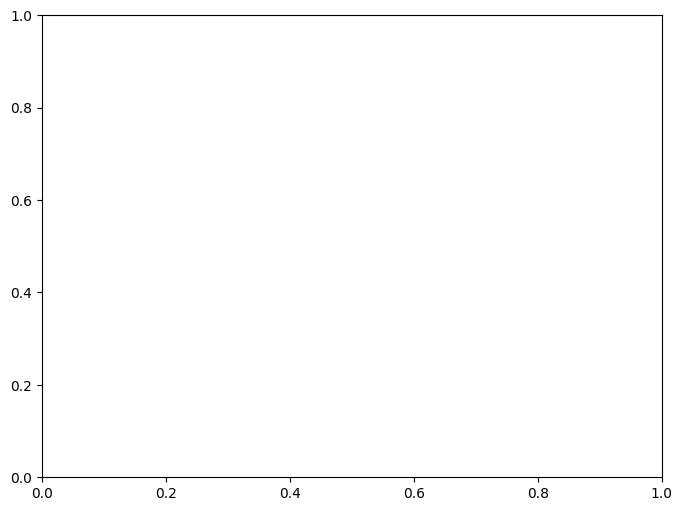

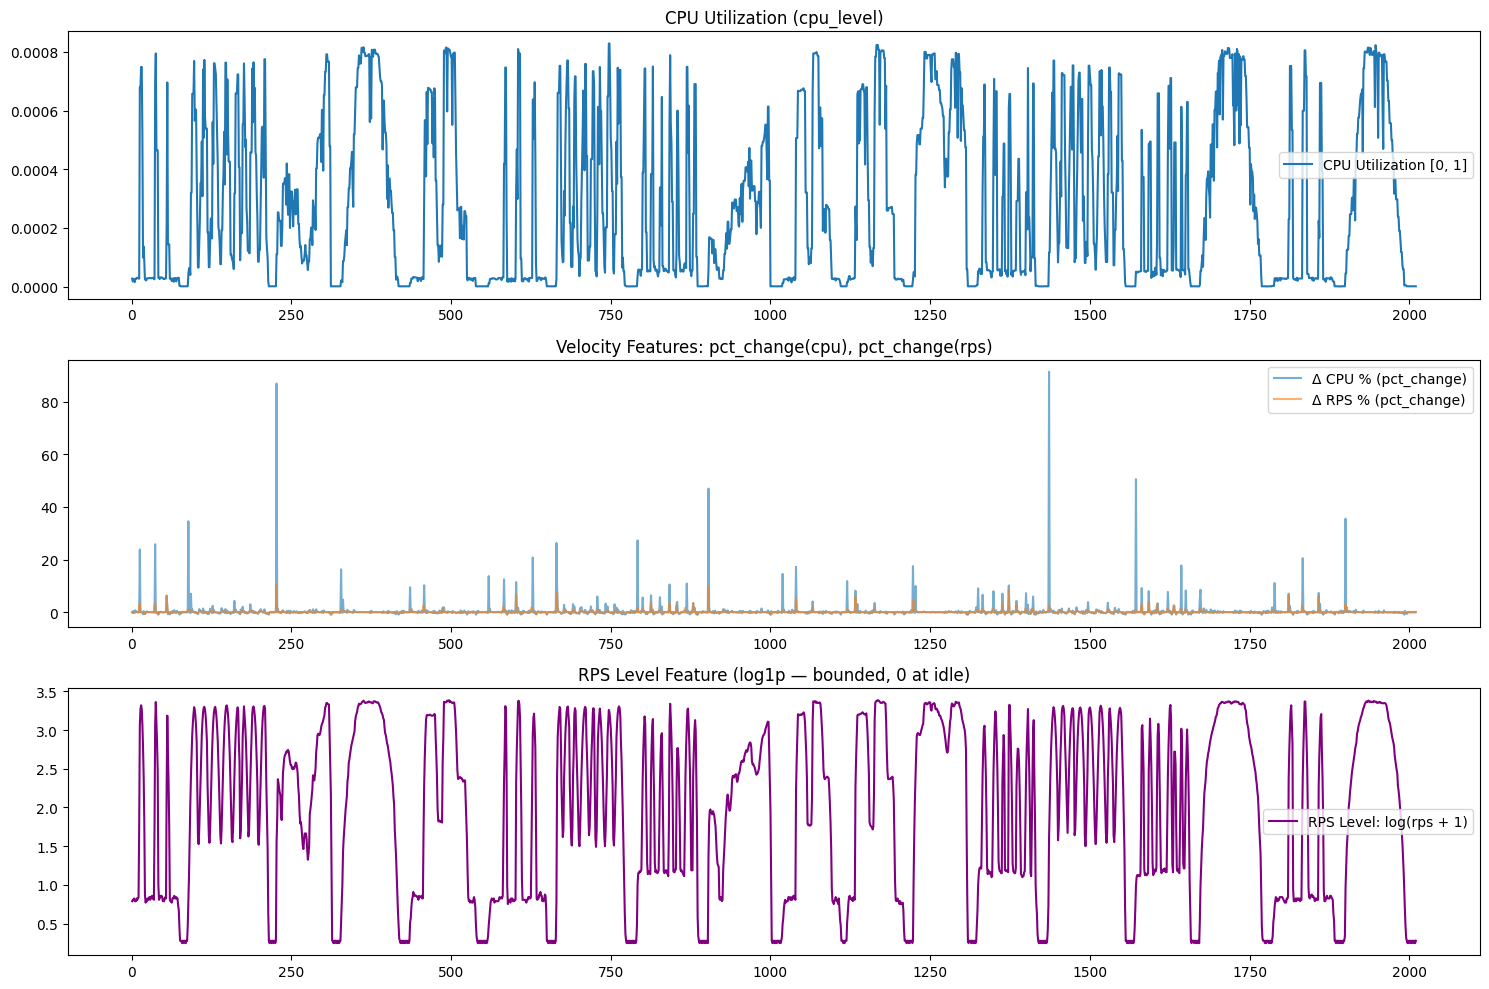

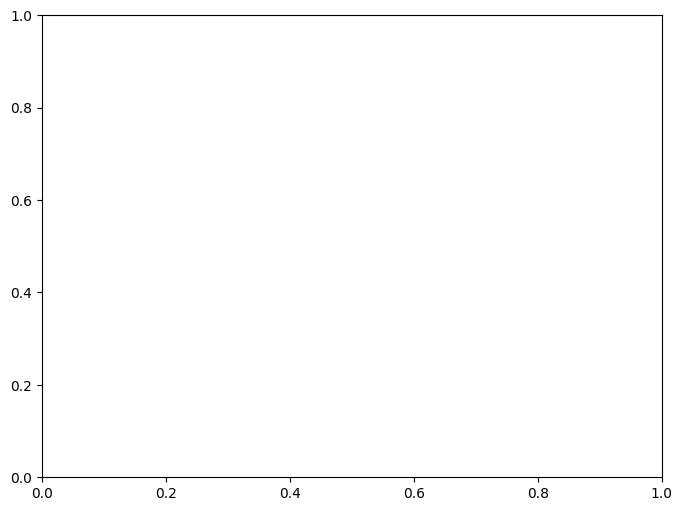

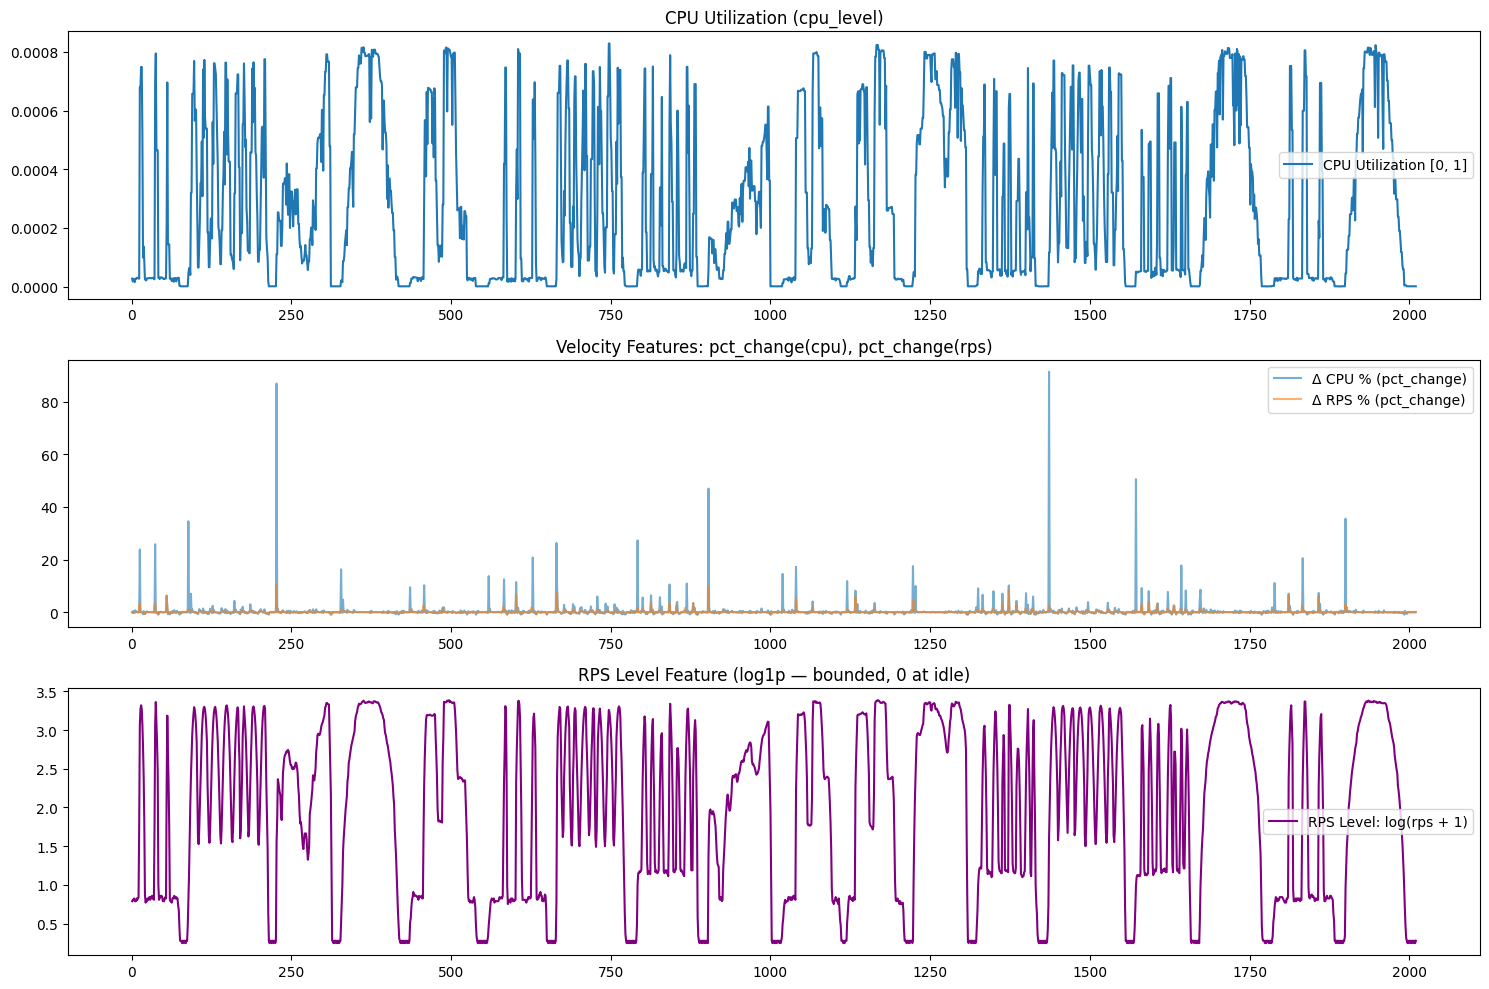

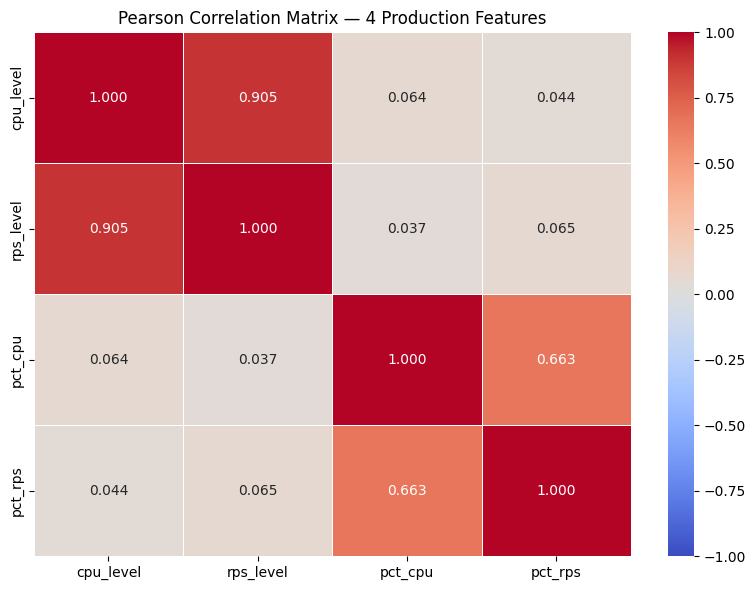

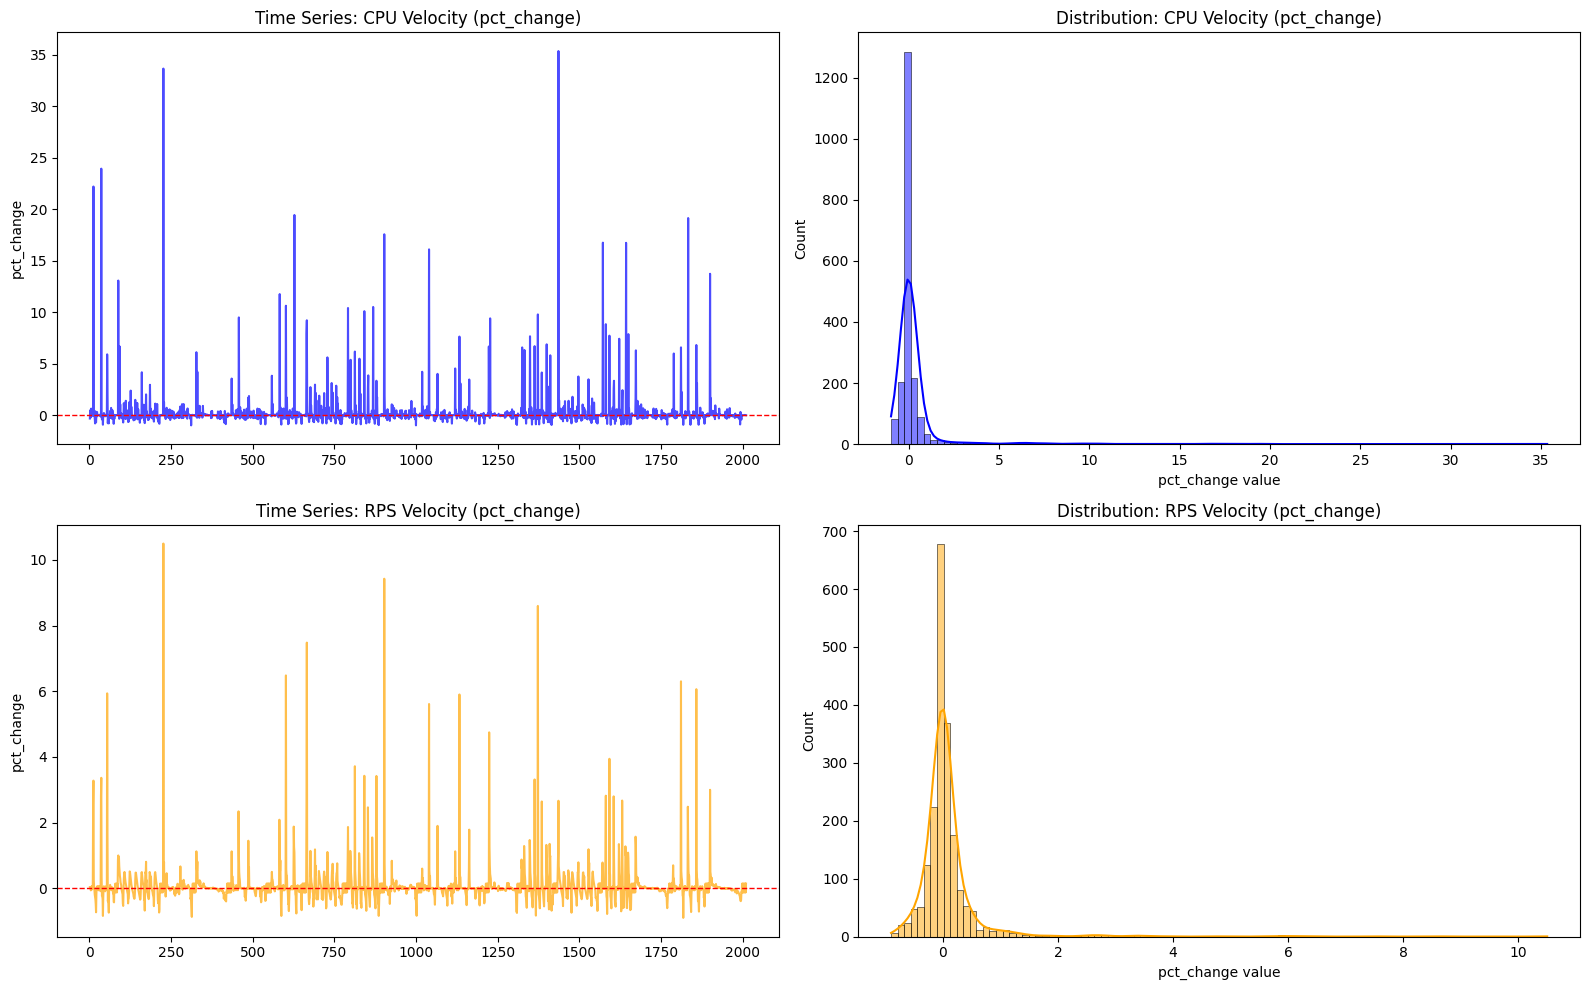

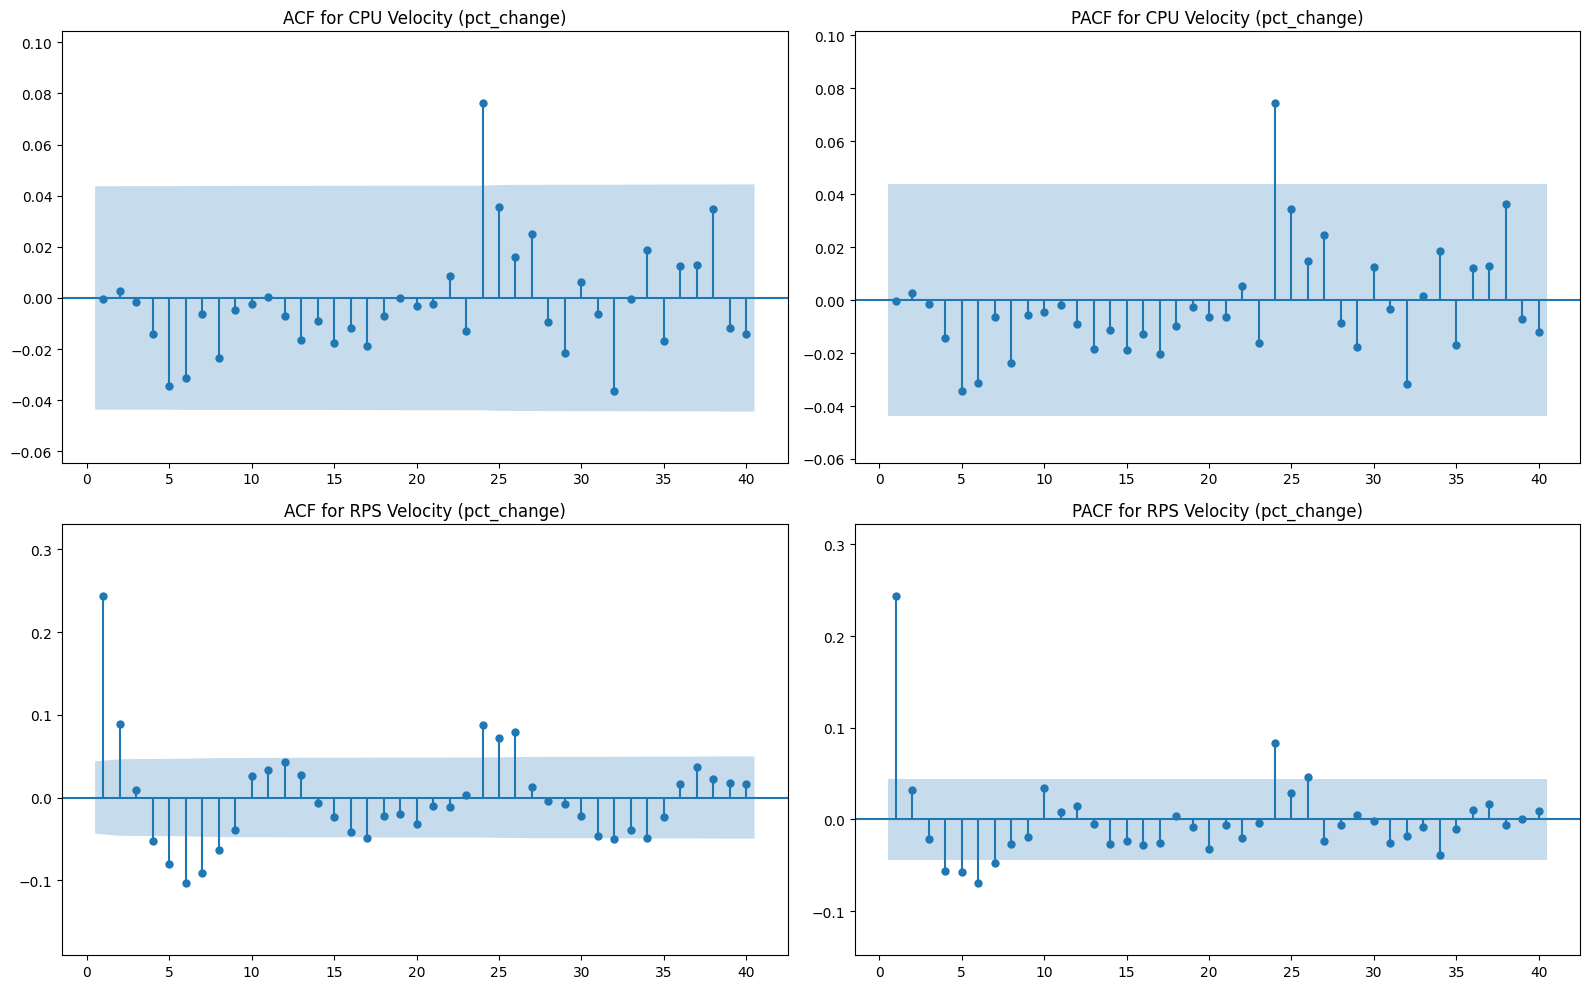

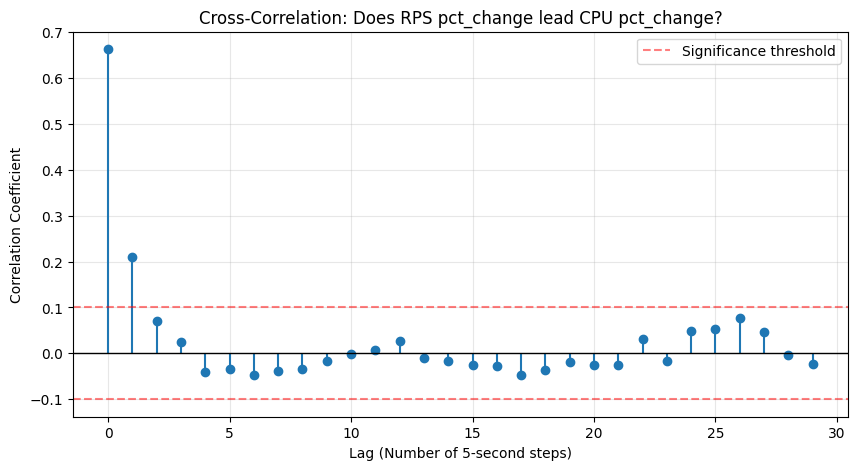

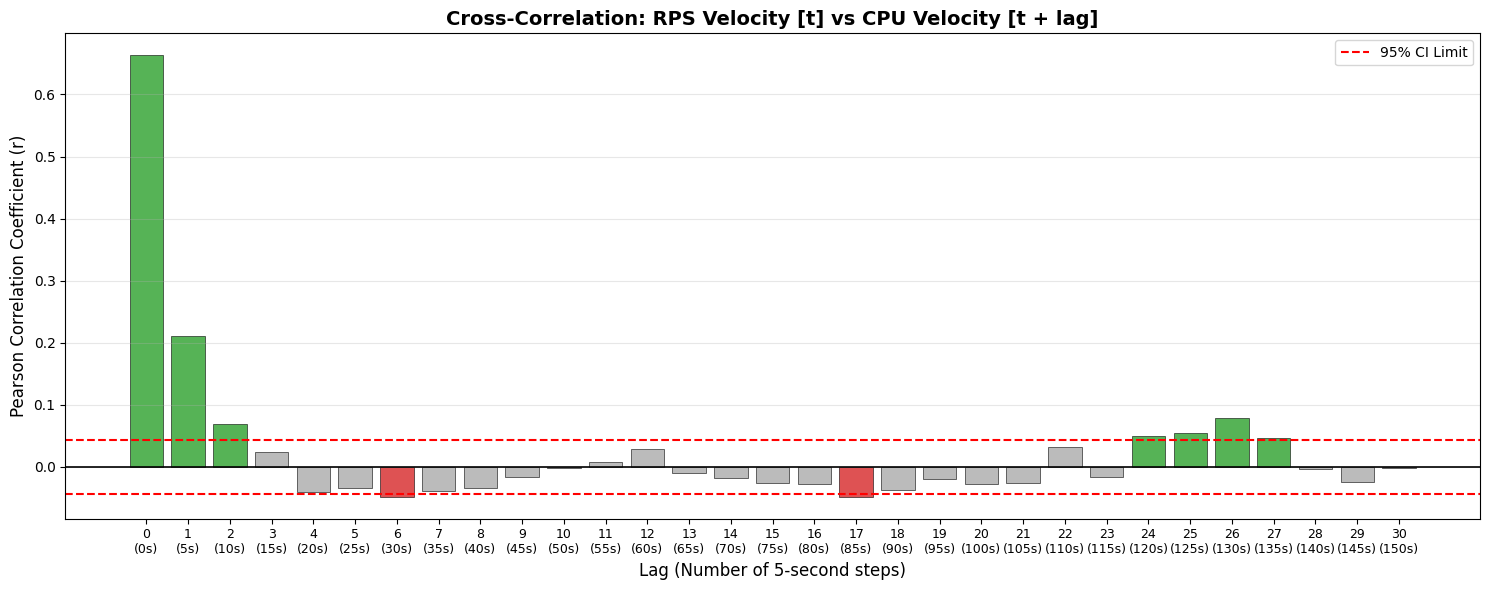

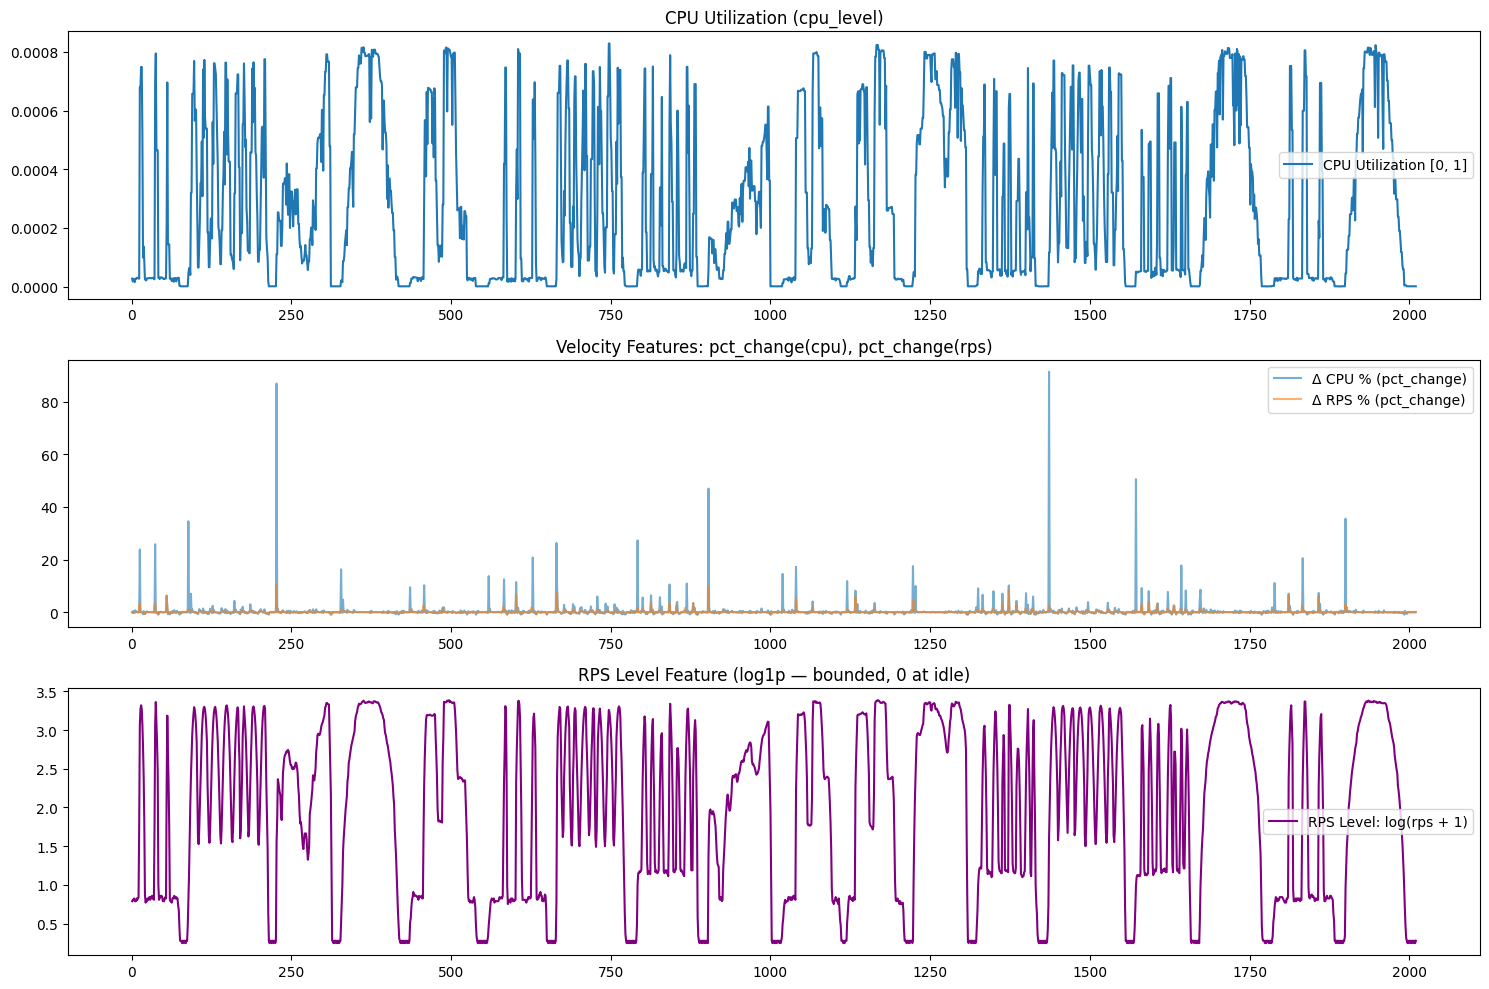

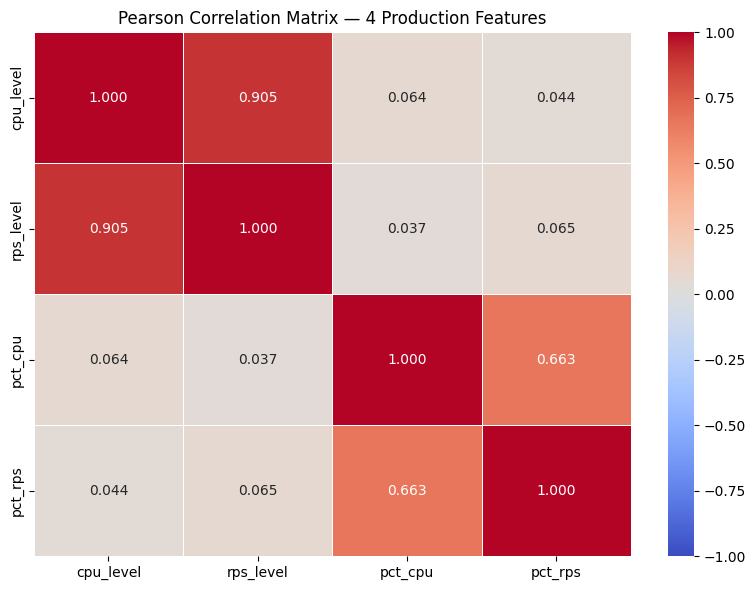

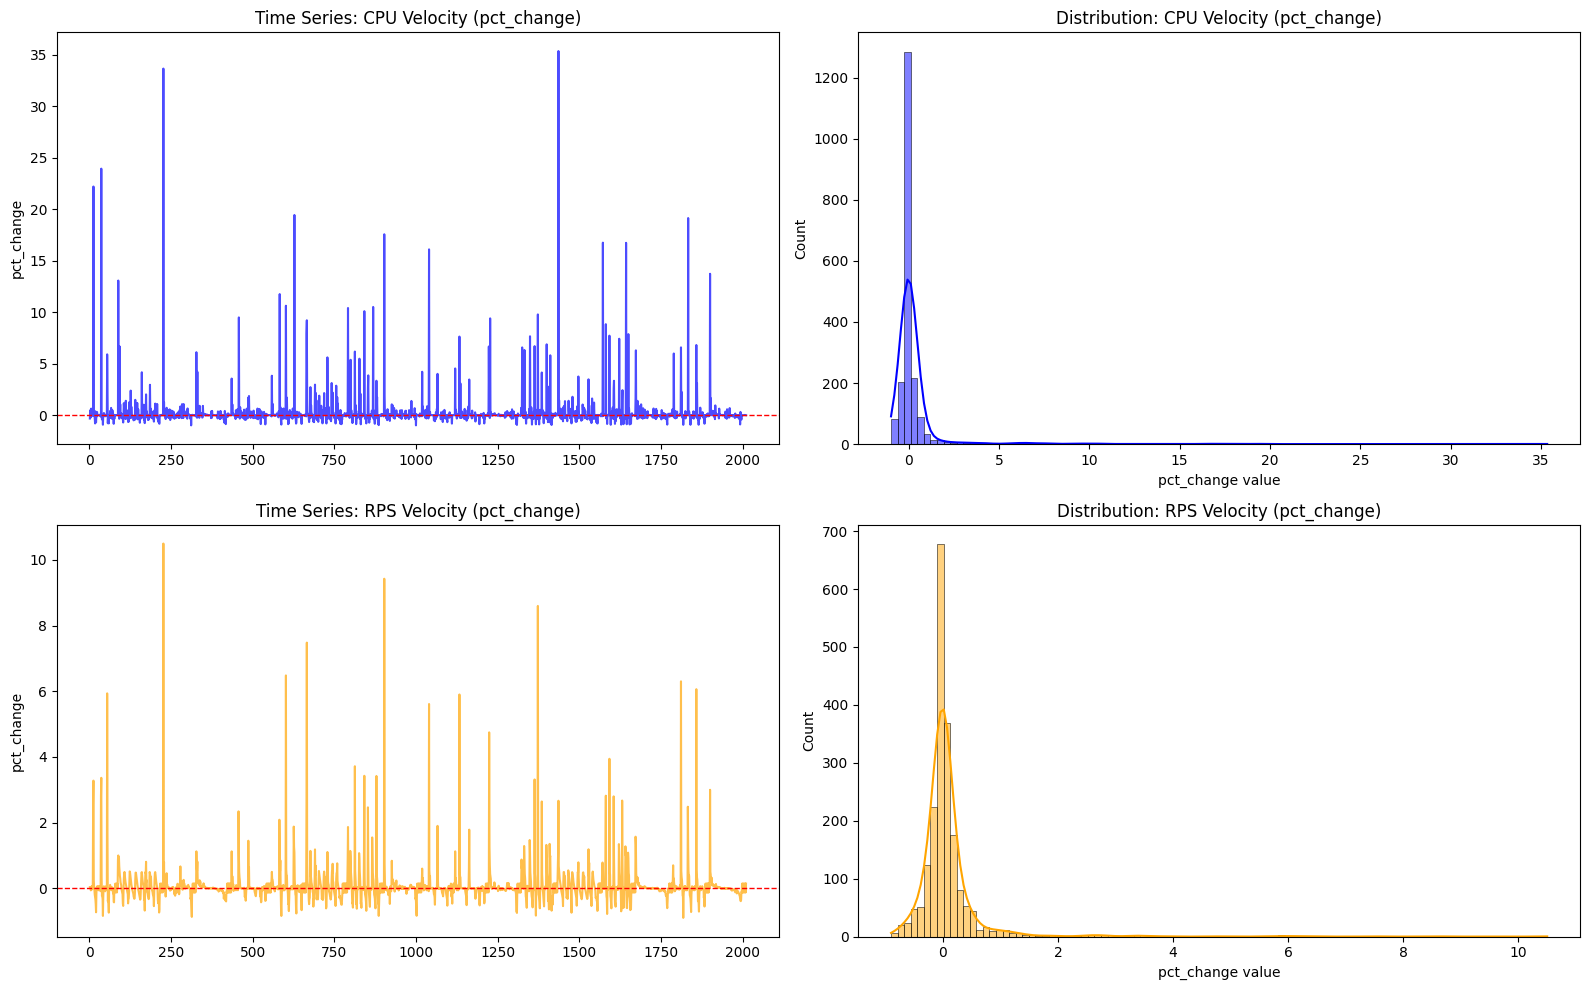

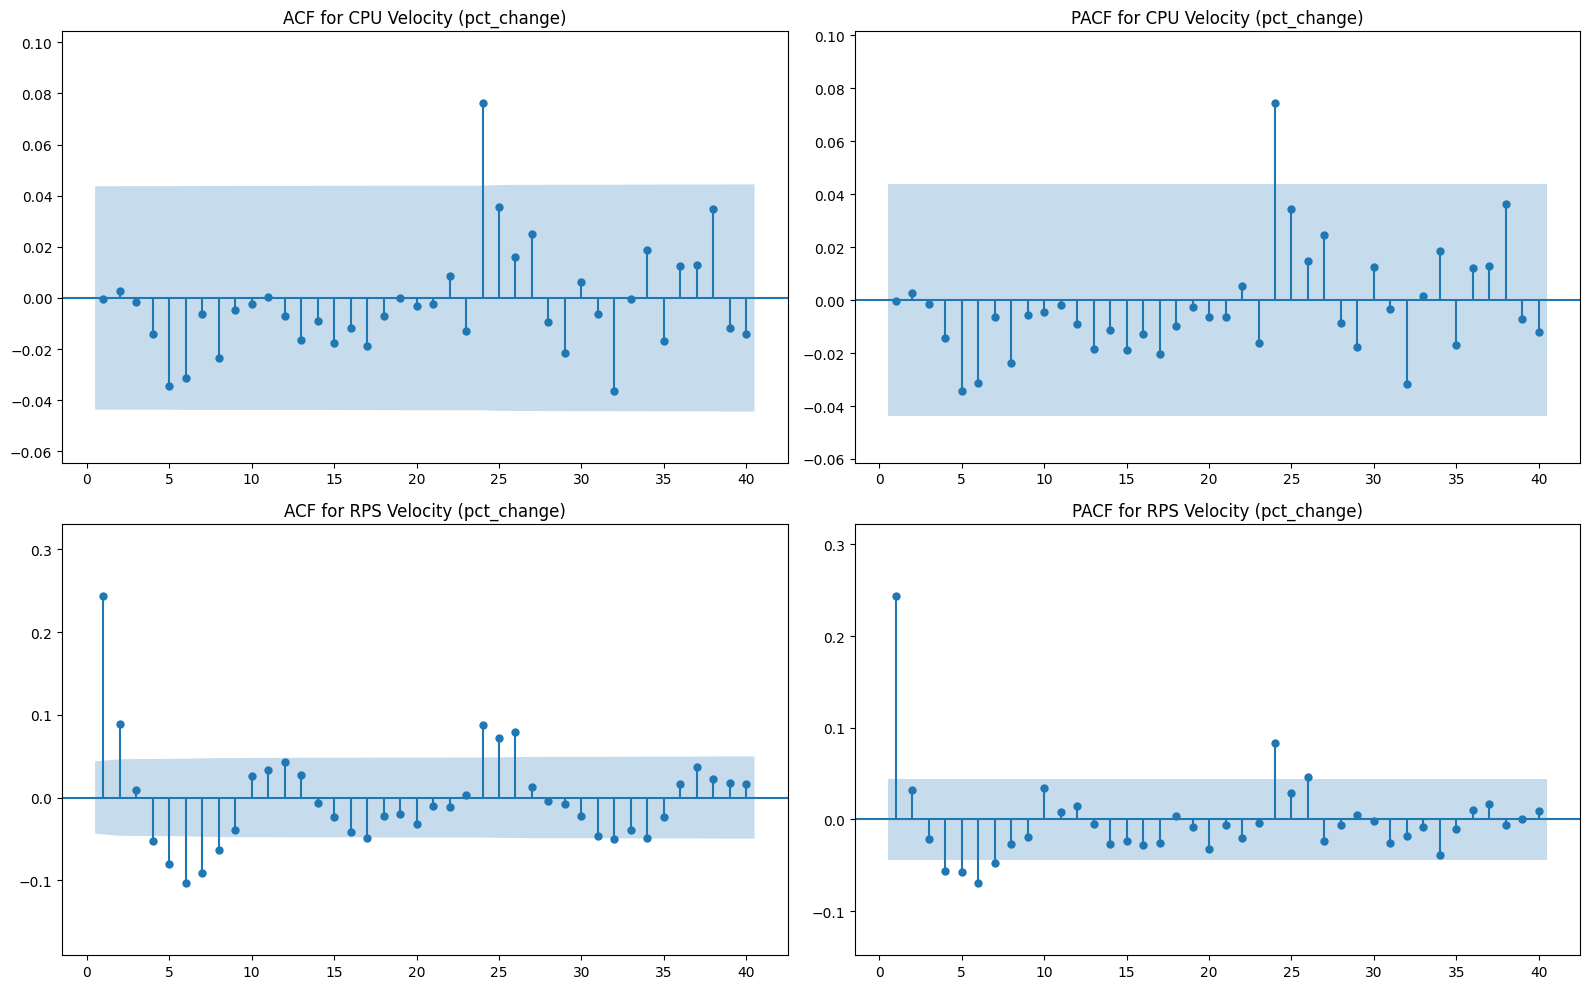

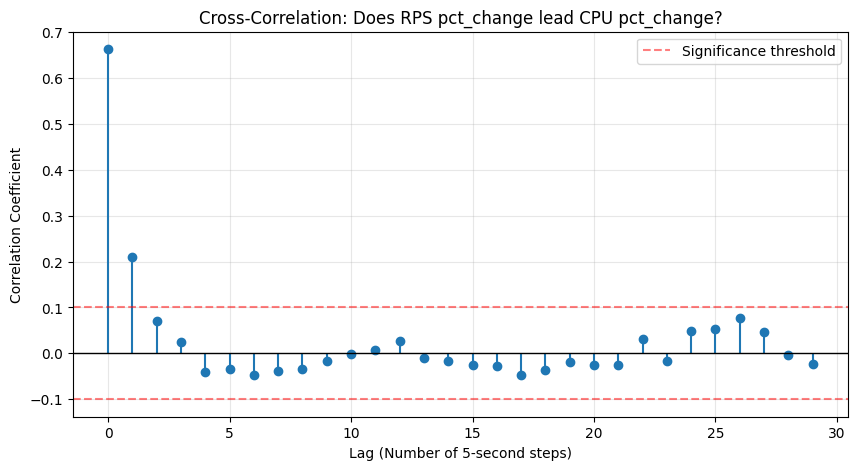

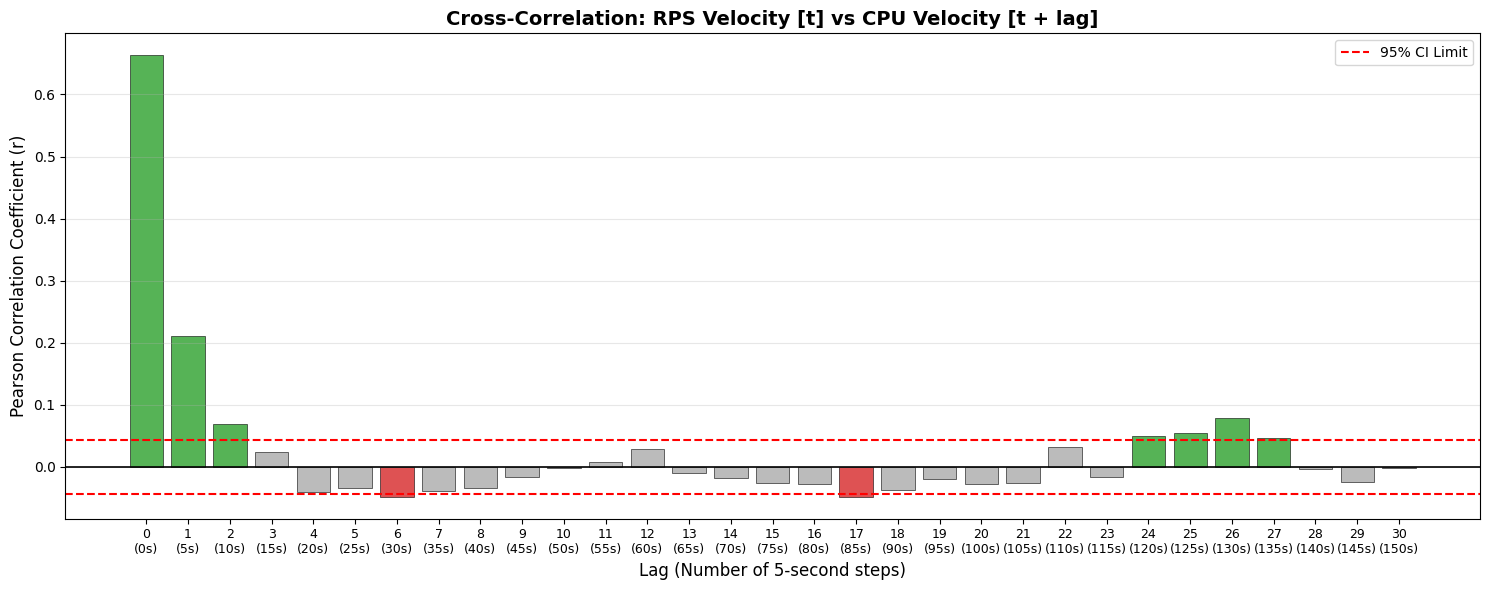

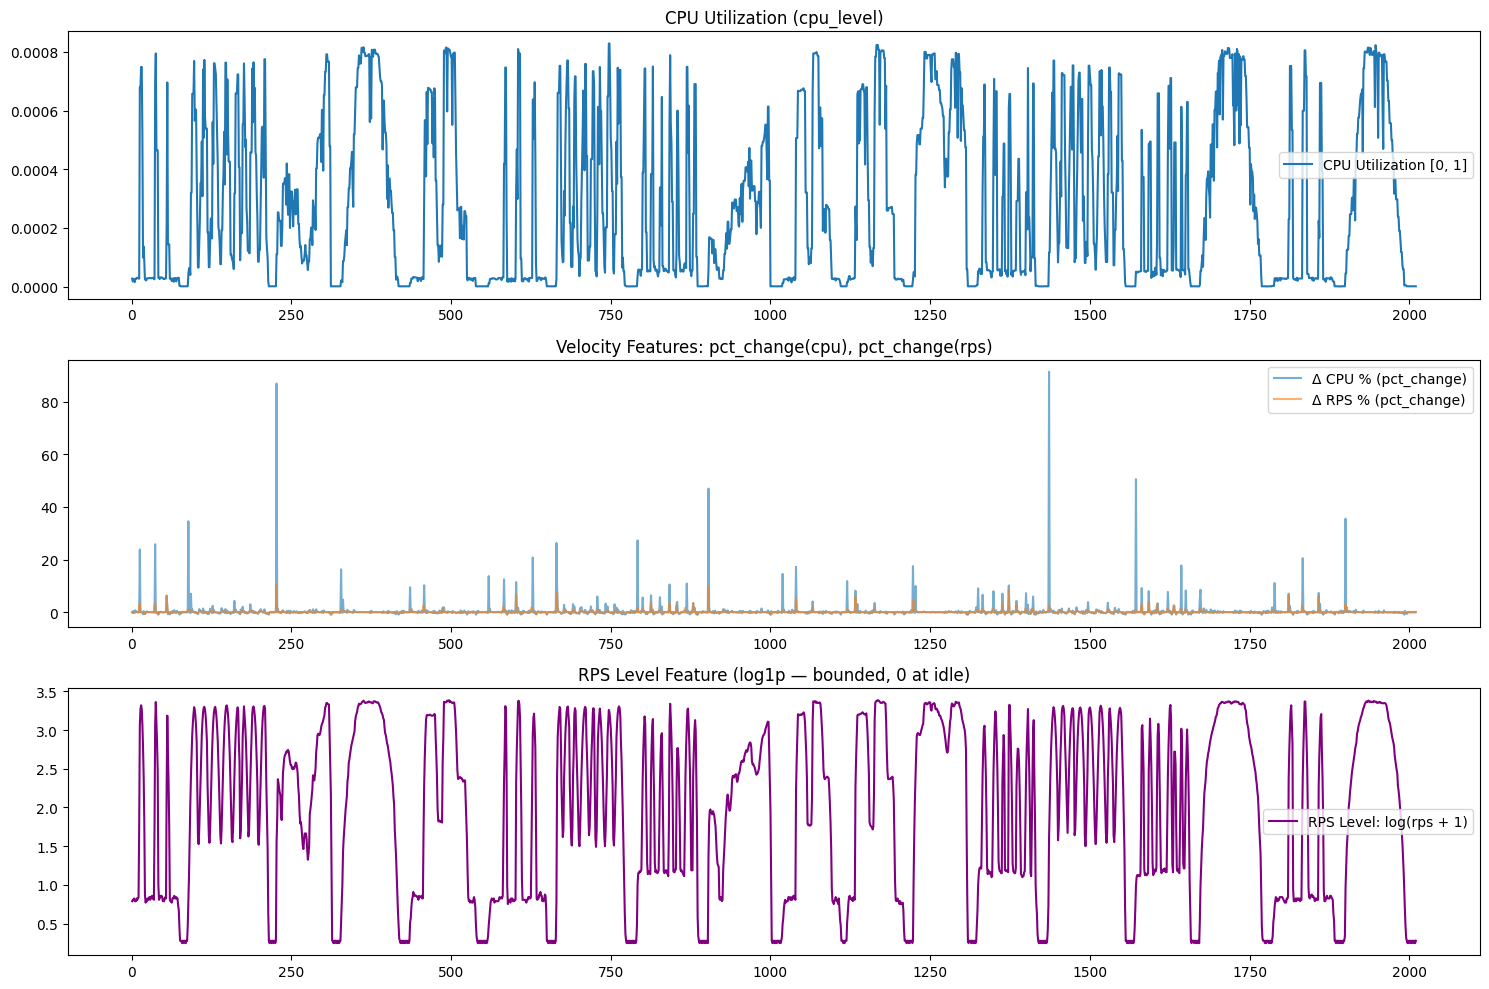

In [77]:
# 3. Visualisation of production feature candidates
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(df['cpu_level'], label='CPU Utilization [0, 1]')
plt.title('CPU Utilization (cpu_level)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['ptc_cpu'], alpha=0.6, label='Δ CPU % (pct_change)')
plt.plot(df['ptc_rps'], alpha=0.6, label='Δ RPS % (pct_change)')
plt.title('Velocity Features: pct_change(cpu), pct_change(rps)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['rps_level'], color='purple', label='RPS Level: log(rps + 1)')
plt.title('RPS Level Feature (log1p — bounded, 0 at idle)')
plt.legend()

plt.tight_layout()

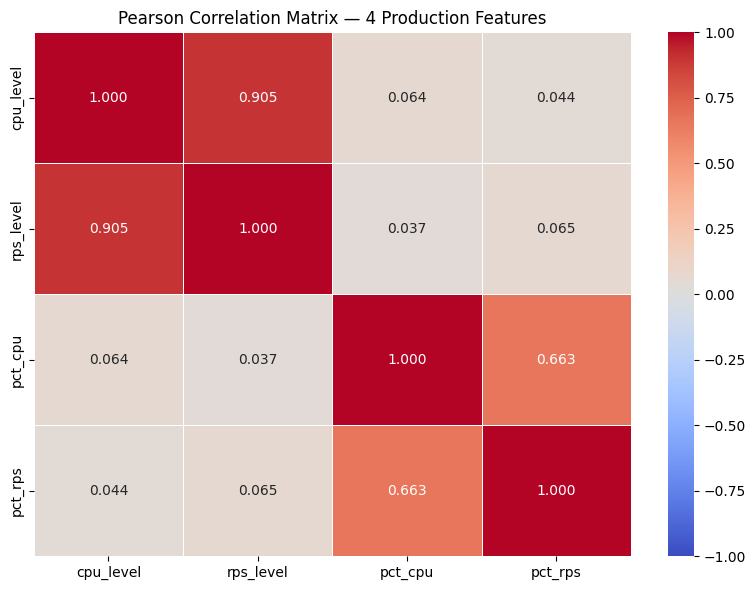

           cpu_level  rps_level  pct_cpu  pct_rps
cpu_level      1.000      0.905    0.064    0.044
rps_level      0.905      1.000    0.037    0.065
pct_cpu        0.064      0.037    1.000    0.663
pct_rps        0.044      0.065    0.663    1.000


In [78]:
# 4. Correlation matrix — production features (pct_cpu/pct_rps, epsilon-guarded)
_EPS = 1e-6
_cpu_safe = df['cpu_level'] + _EPS
_rps_safe = df['input_rps'] + _EPS
_pct_cpu = (_cpu_safe - _cpu_safe.shift(1)) / (_cpu_safe.shift(1) + _EPS)
_pct_rps = (_rps_safe - _rps_safe.shift(1)) / (_rps_safe.shift(1) + _EPS)

_corr_df = df[['cpu_level', 'rps_level']].copy()
_corr_df['pct_cpu'] = _pct_cpu
_corr_df['pct_rps'] = _pct_rps
_corr_df = _corr_df.replace([np.inf, -np.inf], np.nan).dropna()

corr = _corr_df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix — 4 Production Features')
plt.tight_layout()
plt.savefig('eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.savefig('../thesis/figures/eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr.round(3).to_string())

In [79]:
# 5. RPS Level feature stats
print("RPS Level (log1p) Stats:")
print(df['rps_level'].describe())
print()
print("CPU Level Stats:")
print(df['cpu_level'].describe())

RPS Level (log1p) Stats:
count    2010.000000
mean        1.951806
std         1.101974
min         0.246851
25%         0.824181
50%         2.177037
75%         3.034462
max         3.386422
Name: rps_level, dtype: float64

CPU Level Stats:
count    2.010000e+03
mean     2.826579e-04
std      2.827913e-04
min      6.772290e-07
25%      2.835816e-05
50%      1.665695e-04
75%      5.215988e-04
max      8.288091e-04
Name: cpu_level, dtype: float64


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [81]:
EPSILON = 1e-6  # guard against division by zero

df['cpu_safe'] = df['cpu_utilization'] + EPSILON
df['rps_safe'] = df['input_rps'] + EPSILON

In [82]:
# 2. Velocity features: pct_change with epsilon guard
# Formula: v_t = (x_t - x_{t-1}) / (x_{t-1} + ε)  — matches production model_manager.py
df['pct_cpu'] = (df['cpu_safe'] - df['cpu_safe'].shift(1)) / (df['cpu_safe'].shift(1) + EPSILON)
df['pct_rps'] = (df['rps_safe'] - df['rps_safe'].shift(1)) / (df['rps_safe'].shift(1) + EPSILON)

df = df.replace([np.inf, -np.inf], np.nan).dropna()

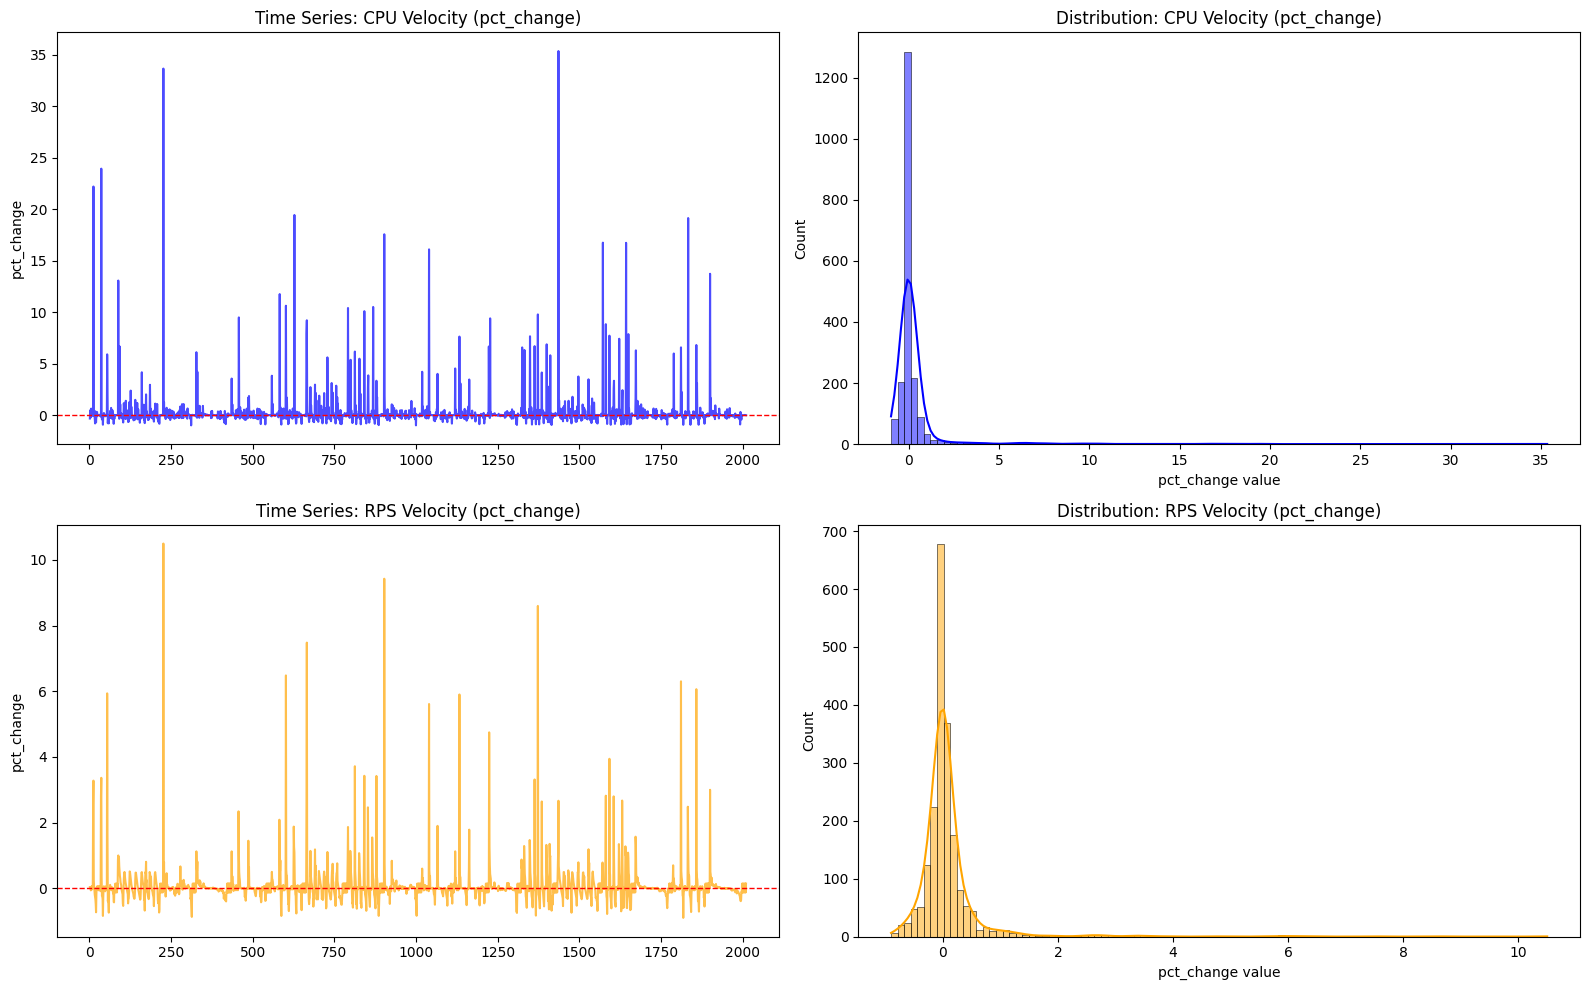

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Time series — CPU velocity
axes[0, 0].plot(df.index, df['pct_cpu'], color='blue', alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Time Series: CPU Velocity (pct_change)')
axes[0, 0].set_ylabel('pct_change')

# 2. Distribution — CPU velocity
sns.histplot(df['pct_cpu'], bins=100, kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Distribution: CPU Velocity (pct_change)')
axes[0, 1].set_xlabel('pct_change value')

# 3. Time series — RPS velocity
axes[1, 0].plot(df.index, df['pct_rps'], color='orange', alpha=0.7)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Time Series: RPS Velocity (pct_change)')
axes[1, 0].set_ylabel('pct_change')

# 4. Distribution — RPS velocity
sns.histplot(df['pct_rps'], bins=100, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Distribution: RPS Velocity (pct_change)')
axes[1, 1].set_xlabel('pct_change value')

plt.tight_layout()
plt.savefig('eda_velocity_features.png')
plt.show()

In [84]:
# 3. ADF Test — stationarity verification for all 4 production features
def print_adf_test(series, name):
    result = adfuller(series.values)
    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    if result[1] <= 0.05:
        print("Verdict: STATIONARY (Reject H0)\n")
    else:
        print("Verdict: NON-STATIONARY (Fail to reject H0)\n")

print_adf_test(df['cpu_level'],  'CPU Level  (cpu_utilization [0,1])')
print_adf_test(df['rps_level'],  'RPS Level  (log1p(RPS))')
print_adf_test(df['pct_cpu'],    'CPU Velocity (pct_change)')
print_adf_test(df['pct_rps'],    'RPS Velocity (pct_change)')

--- ADF Test for CPU Level  (cpu_utilization [0,1]) ---
ADF Statistic: -6.9823
p-value: 8.1329e-10
Verdict: STATIONARY (Reject H0)

--- ADF Test for RPS Level  (log1p(RPS)) ---
ADF Statistic: -7.0222
p-value: 6.5011e-10
Verdict: STATIONARY (Reject H0)

--- ADF Test for CPU Velocity (pct_change) ---
ADF Statistic: -44.8024
p-value: 0.0000e+00
Verdict: STATIONARY (Reject H0)

--- ADF Test for RPS Velocity (pct_change) ---
ADF Statistic: -19.3262
p-value: 0.0000e+00
Verdict: STATIONARY (Reject H0)



Saved eda_acf_pacf.png


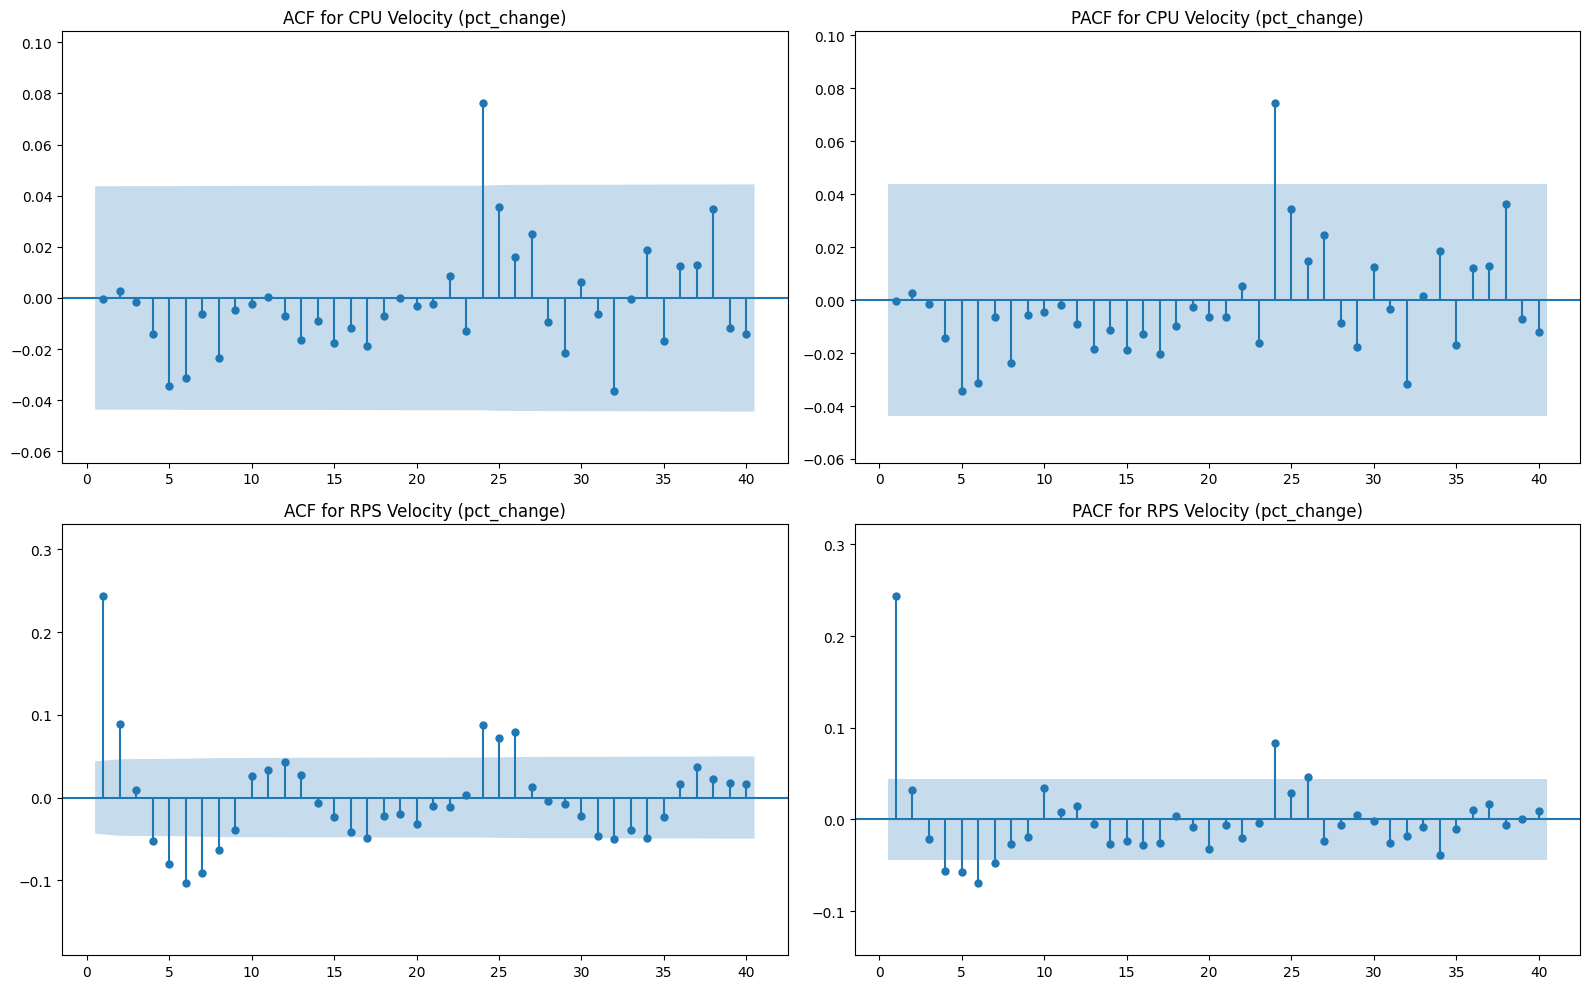

In [85]:
# 4. ACF and PACF — window size analysis on velocity features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(df['pct_cpu'],  lags=40, zero=False, ax=axes[0, 0], title='ACF for CPU Velocity (pct_change)')
plot_pacf(df['pct_cpu'], lags=40, zero=False, ax=axes[0, 1], title='PACF for CPU Velocity (pct_change)')
plot_acf(df['pct_rps'],  lags=40, zero=False, ax=axes[1, 0], title='ACF for RPS Velocity (pct_change)')
plot_pacf(df['pct_rps'], lags=40, zero=False, ax=axes[1, 1], title='PACF for RPS Velocity (pct_change)')

# Rescale each axis to actual data range (statsmodels defaults to [-1, 1])
for ax in axes.flat:
    lines = [l for l in ax.get_lines() if len(l.get_ydata()) > 1]
    if lines:
        vals = np.concatenate([l.get_ydata() for l in lines])
        pad = (vals.max() - vals.min()) * 0.25 or 0.05
        ax.set_ylim(vals.min() - pad, vals.max() + pad)

plt.tight_layout()
fig.savefig('eda_acf_pacf.png',                  dpi=150, bbox_inches='tight')
fig.savefig('../thesis/figures/eda_acf_pacf.png', dpi=150, bbox_inches='tight')
print('Saved eda_acf_pacf.png')

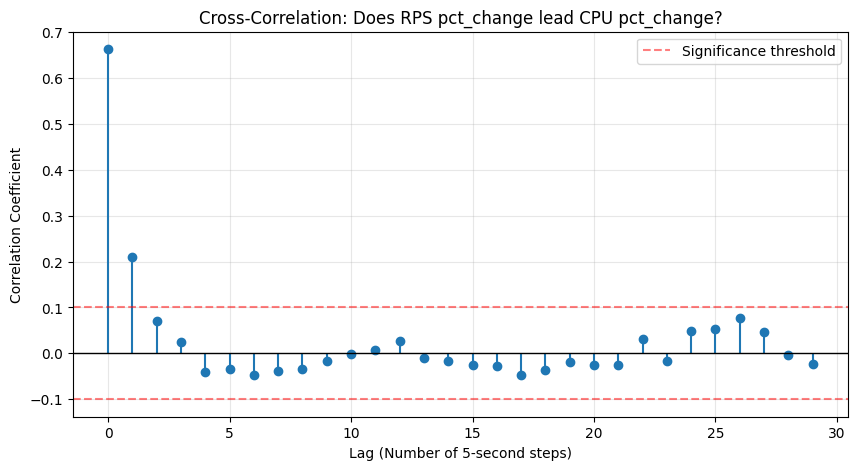

In [86]:
# 5. Cross-Correlation (Lag Analysis: RPS velocity → CPU velocity)
lags = 30  # 30 steps × 5s = 150s lookahead
cross_corr = ccf(df['pct_cpu'], df['pct_rps'], adjusted=False)

plt.figure(figsize=(10, 5))
plt.stem(range(lags), cross_corr[:lags], basefmt=" ")
plt.axhline(0, color='black', linewidth=1)
plt.axhline( 0.1, color='red', linestyle='--', alpha=0.5, label='Significance threshold')
plt.axhline(-0.1, color='red', linestyle='--', alpha=0.5)
plt.title('Cross-Correlation: Does RPS pct_change lead CPU pct_change?')
plt.xlabel('Lag (Number of 5-second steps)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('eda_cross_correlation.png')

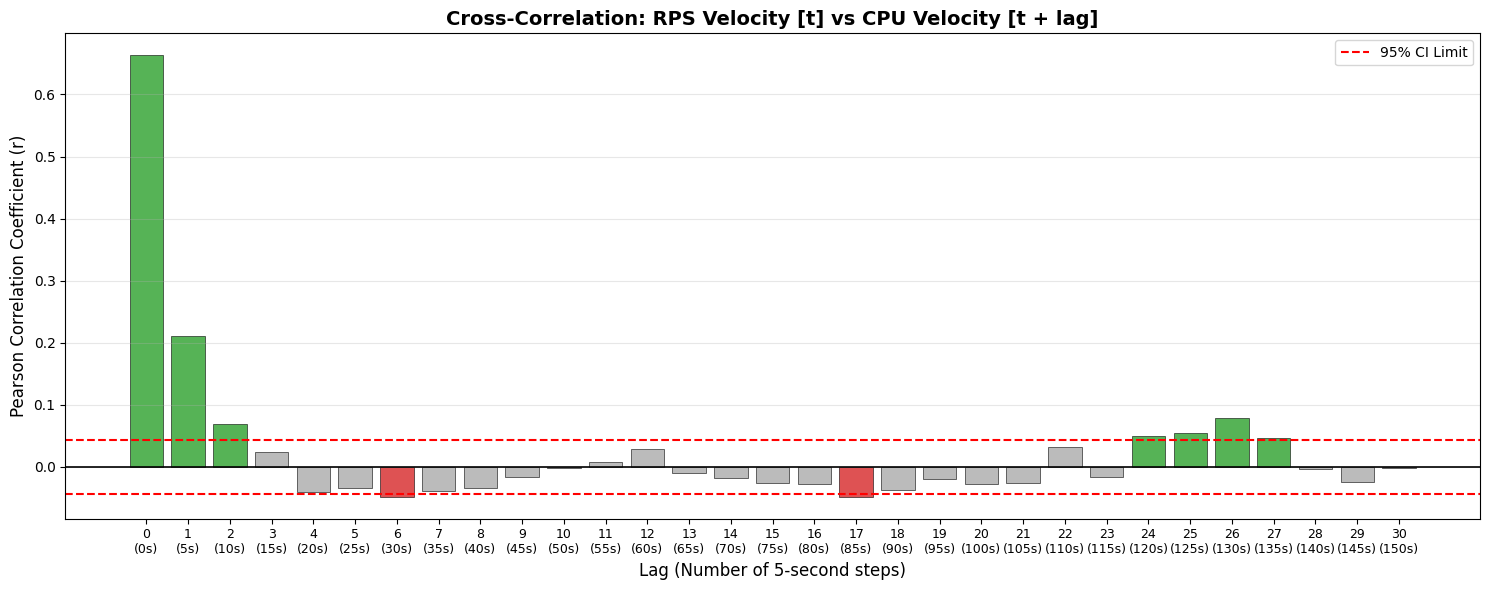

Peak correlation: r = 0.663 at lag = 0 steps (0s)


In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_clean = df[['pct_rps', 'pct_cpu']].dropna()

max_lag = 30  # 30 × 5s = 150s

# Z-score normalisation for Pearson r
rps_z = (df_clean['pct_rps'].values - df_clean['pct_rps'].mean()) / df_clean['pct_rps'].std()
cpu_z = (df_clean['pct_cpu'].values - df_clean['pct_cpu'].mean()) / df_clean['pct_cpu'].std()

lags = list(range(0, max_lag + 1))
xcorr = [
    np.corrcoef(rps_z[:len(rps_z) - lag] if lag else rps_z,
                cpu_z[lag:]               if lag else cpu_z)[0, 1]
    for lag in lags
]

ci = 1.96 / np.sqrt(len(rps_z))

fig, ax = plt.subplots(figsize=(15, 6))

bar_colors = ["#2ca02c" if x > ci else ("#aaaaaa" if x > -ci else "#d62728") for x in xcorr]

ax.bar(lags, xcorr, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline( ci, color="red", linestyle="--", linewidth=1.5, label="95% CI Limit")
ax.axhline(-ci, color="red", linestyle="--", linewidth=1.5)
ax.axhline(0,   color="black", linewidth=1.2)

ax.set_title("Cross-Correlation: RPS Velocity [t] vs CPU Velocity [t + lag]", fontsize=14, fontweight='bold')
ax.set_xlabel("Lag (Number of 5-second steps)", fontsize=12)
ax.set_ylabel("Pearson Correlation Coefficient (r)", fontsize=12)

ax.set_xticks(lags)
ax.set_xticklabels([f"{l}\n({l*5}s)" for l in lags], fontsize=9)

ax.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_cross_correlation_bars.png', dpi=300)
plt.show()

best_lag = int(np.argmax(xcorr))
print(f"Peak correlation: r = {xcorr[best_lag]:.3f} at lag = {best_lag} steps ({best_lag * 5}s)")